#### Exploratory Data Analysis on the dataset that is used for training model IndoBERT, this is being done in reason because the overfitting is really high

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.feature_extraction.text import CountVectorizer

warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("../DataScript/PRDECT-ID Dataset.csv")
df.head()

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


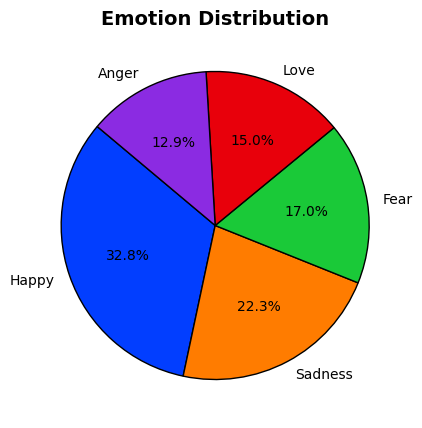

In [20]:
colors = sns.color_palette("bright", n_colors=len(df['Emotion'].unique()))

plt.figure(figsize=(5, 5))  # Set figure size
plt.pie(df['Emotion'].value_counts(), 
        labels=df['Emotion'].value_counts().index, 
        autopct='%1.1f%%', 
        colors=colors, 
        startangle=140, 
        wedgeprops={'edgecolor': 'black'})
    
plt.title("Emotion Distribution", fontsize=14, fontweight='bold')

plt.show()

In [ ]:
df['text'] = df['text'].fillna('')
df[df['text'] == ''].count()

text     2
label    2
dtype: int64

In [ ]:
df.dropna(subset=['text'], inplace=True)

#### Length Analysis

In [ ]:
df['length'] = df['text'].str.len()
df.head(5)

,text,label,length
0,"Itemnya bagus tapi buku buku ini sangat mahal,...",Love,157
1,jangan samain packing sama ikan,Anger,31
2,"Tidak jelas bahwa tidak ada instruksi, rakitny...",Anger,111
3,Packing oke banget ikannya juga mantebbb langg...,Love,54
4,Susah bikinnya ga ngerti ribet packing juga ku...,Anger,101


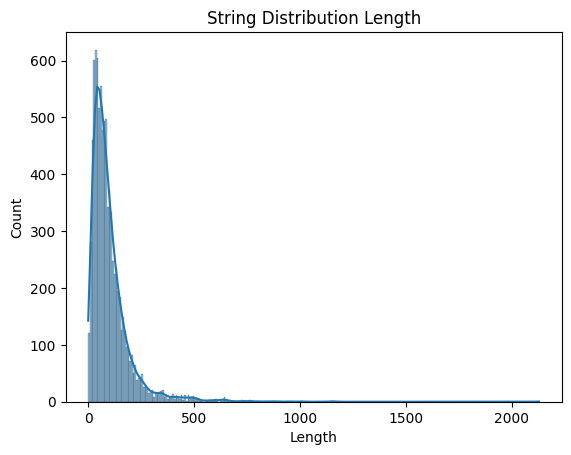

In [ ]:
sns.histplot(df['length'], kde=True)
plt.xlabel('Length')
plt.title('String Distribution Length')

plt.show()

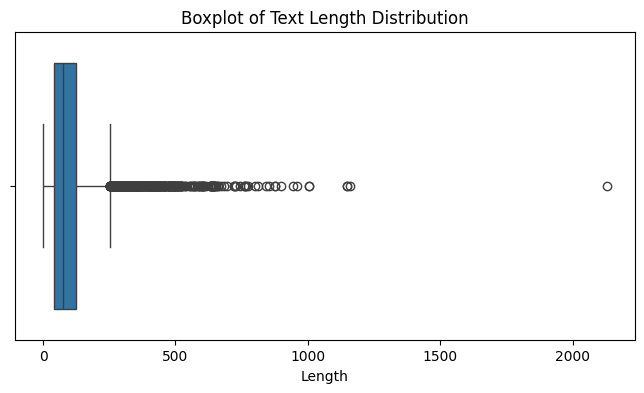

In [ ]:
# Plotting the boxplot for the 'length' column
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['length'])
plt.xlabel('Length')
plt.title('Boxplot of Text Length Distribution')
plt.show()

In [ ]:
df[df['length'] < 20].count()

text      534
label     534
length    534
dtype: int64

In [ ]:
print(f'Mean: {df['length'].mean()}')
print(f'Mean: {df['length'].median()}')
print(f'Mean: {df['length'].std()}')

Mean: 101.13163841807909
Mean: 75.0
Mean: 99.4848487322239


#### N Gram

In [ ]:
cv = CountVectorizer(ngram_range=(2,2))
bigrams = cv.fit_transform(df['text'])

In [ ]:
count_values = bigrams.toarray().sum(axis=0)
ngram_freq = pd.DataFrame(sorted([(count_values[i], k) for k, i in cv.vocabulary_.items()], reverse = True))
ngram_freq.columns = ["frequency", "ngram"]

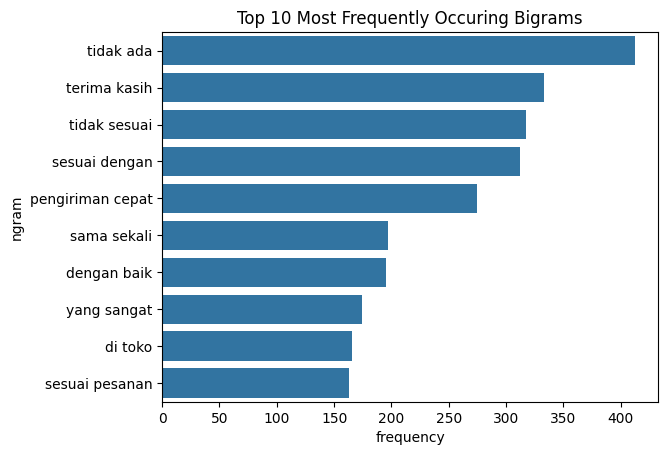

In [ ]:
sns.barplot(x=ngram_freq['frequency'][:10], y=ngram_freq['ngram'][:10])
plt.title('Top 10 Most Frequently Occuring Bigrams')
plt.show()